# E-commerce Product Delivery Prediction

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h3 align="left"><font color=red>Problem:</font></h3>

This project aims to enhance the understanding of product delivery patterns and customer behavior for an international e-commerce company specializing in electronic products. By leveraging machine learning, the project seeks to predict whether products will reach customers on time. The goal is to develop robust machine learning models to accurately predict product delivery timeliness, enabling the company to improve customer satisfaction, optimize logistics, and gain insights into factors affecting delivery performance.

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Objectives:</font></h3>

* __Explore the Dataset__: Uncover patterns, distributions, and relationships within the data.
* __Conduct Extensive Exploratory Data Analysis (EDA)__: Dive deep into bivariate relationships against the target.
* __Preprocessing Steps__:
  - Remove irrelevant features
  - Address missing values
  - Analyze outliers
  - Encode categorical variables
* __Model Building__:
  - Establish pipelines for models that require scaling
  - Implement and tune classification models including Logistic Regression, KNN, Decision Trees, and Random Forest
* __Evaluate and Compare Model Performance__: Utilize precision, recall, and F1-score to gauge models' effectiveness.


<a id="importlibrary"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from joblib import dump

<a id="loadfile"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read CSV File</p>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

First of all, let's load the dataset:

In [60]:
df = pd.read_csv("E_Commerce.csv")

<a id="datasetoverview"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview</p>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h2 align="left"><font color=red>Dataset Description:</font></h2>
    
| __Variable__ | __Description__ |
|     :---      |       :---      |      
| __ID__ | Number of Customers |
| __Warehouse_block__ | The Company have big Warehouse which is divided into block such as A,B,C,D,E |
| __Mode_of_Shipment__ | The Company Ships the products in multiple way such as Ship, Flight and Road |
| __Customer_care_calls__ | The number of calls made from enquiry for enquiry of the shipment |
| __Customer_rating__ | The company has rated from every customer. 1 is the lowest (Worst), 5 is the highest (Best) |                     
| __Cost_of_the_Product__ | Cost of the Product in US Dollars |
| __Prior_purchases__ | The Number of Prior Purchase |  
| __Product_importance__ | The company has categorized the product in the various parameter such as low, medium high |                      
| __Gender__ | Male and Female |
| __Discount_offered__ | Discount offered on that specific product |
| __Weight_in_gms__ | It is the weight in grams |                      
| __Reached.on.Time_Y.N__ | It is the target variable, where 1 Indicates that the product has NOT reached on time and 0 indicates it has reached on time |

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 3.1 |</span><span style='color:red'> View Data</span></b>  

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">
    
Next, We will dive into a detailed exploration of the dataset:

In [61]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 3.2 |</span><span style='color:red'> Dataset Columns and Rows</span></b>

In [62]:
df.shape

(10999, 12)

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 3.3 |</span><span style='color:red'> Dataset Basic Information</span></b>

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.1 MB


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

* __Number of Entries__: The dataset consists of __10999 entries__, ranging from index 0 to 10999.
    
    
* __Columns__: There are __12 columns__ in the dataset corresponding to various attributes of the product and customer attributes.
    
    
* __Data Types__:
    - Most of the columns (8 out of 12) are of the __int64__ data type.
    
    
* __Missing Values__: There don't appear to be any missing values in the dataset as each column has 10999 non-null entries.

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 3.4 |</span><span style='color:red'> Statistical Data</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

Let's dive into the summary statistics for our __numerical__ attributes:

In [64]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


<a id="eda"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | EDA (Exploratory Data Analysis)</p>

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 4.1 |</span><span style='color:red'> Check Target Column</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

From the given dataset we can identify that Reached.on.Time_Y.N is the target column

In [65]:
df["Reached.on.Time_Y.N"].value_counts()

Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

In [66]:
df["Reached.on.Time_Y.N"].value_counts(normalize=True) * 100

Reached.on.Time_Y.N
1    59.669061
0    40.330939
Name: proportion, dtype: float64

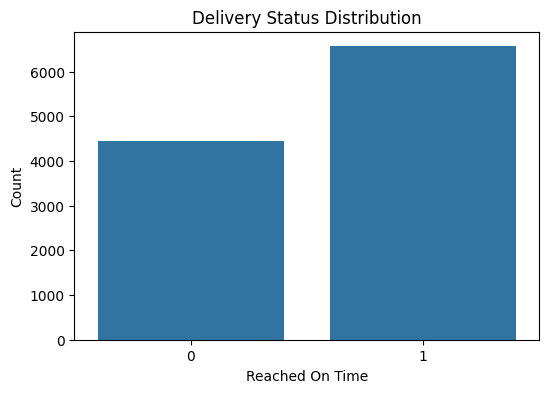

In [67]:
plt.figure(figsize=(6,4))

sns.countplot(x="Reached.on.Time_Y.N", data=df)

plt.title("Delivery Status Distribution")
plt.xlabel("Reached On Time")
plt.ylabel("Count")
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

The classes are moderately imbalanced but not severely — roughly a 60/40 split rather than 95/5.

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 4.2 |</span><span style='color:red'> Univariate Analysis</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

For our __Exploratory Data Analysis (EDA)__, we'll take it in two main steps:

>__1. Univariate Analysis__: Here, we'll focus on one feature at a time to understand its distribution and range.
>
>__2. Bivariate Analysis__: In this step, we'll explore the relationship between each feature and the target variable. This helps us figure out the importance and influence of each feature on the target outcome.

With these two steps, we aim to gain insights into the individual characteristics of the data and also how each feature relates to our main goal: __predicting the target variable__.

In [68]:
# Analyze Numerical Columns
numerical_cols = [
    "Customer_care_calls",
    "Customer_rating",
    "Cost_of_the_Product",
    "Prior_purchases",
    "Discount_offered",
    "Weight_in_gms"
]

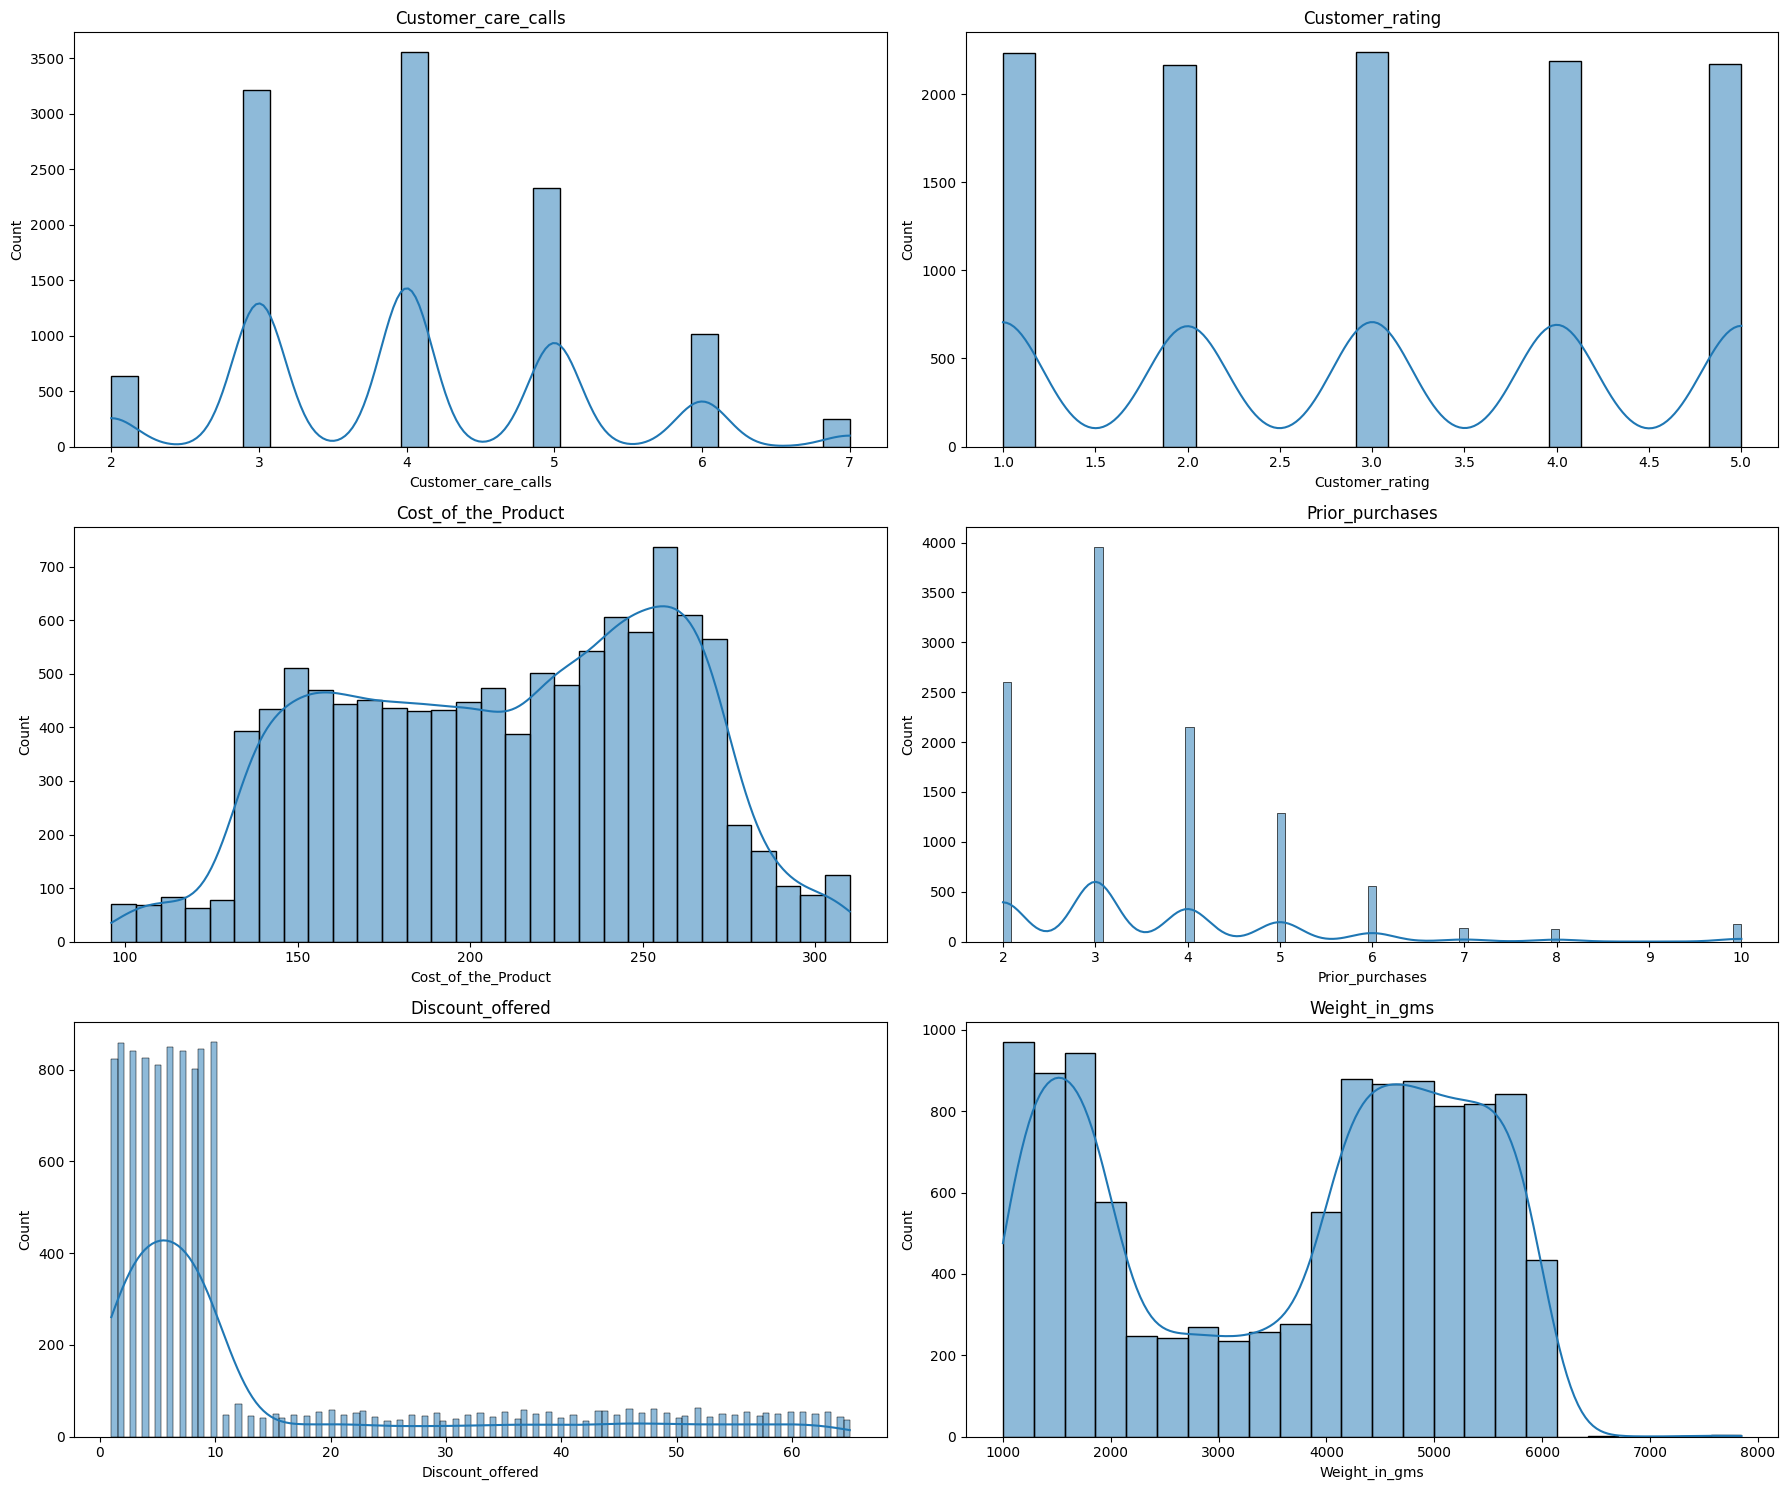

In [69]:
n_cols = 2
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()  # Convert 2D array of axes to 1D

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [70]:
# Analyze Categorical Columns
categorical_cols = [
    "Warehouse_block",
    "Mode_of_Shipment",
    "Product_importance",
    "Gender"
]

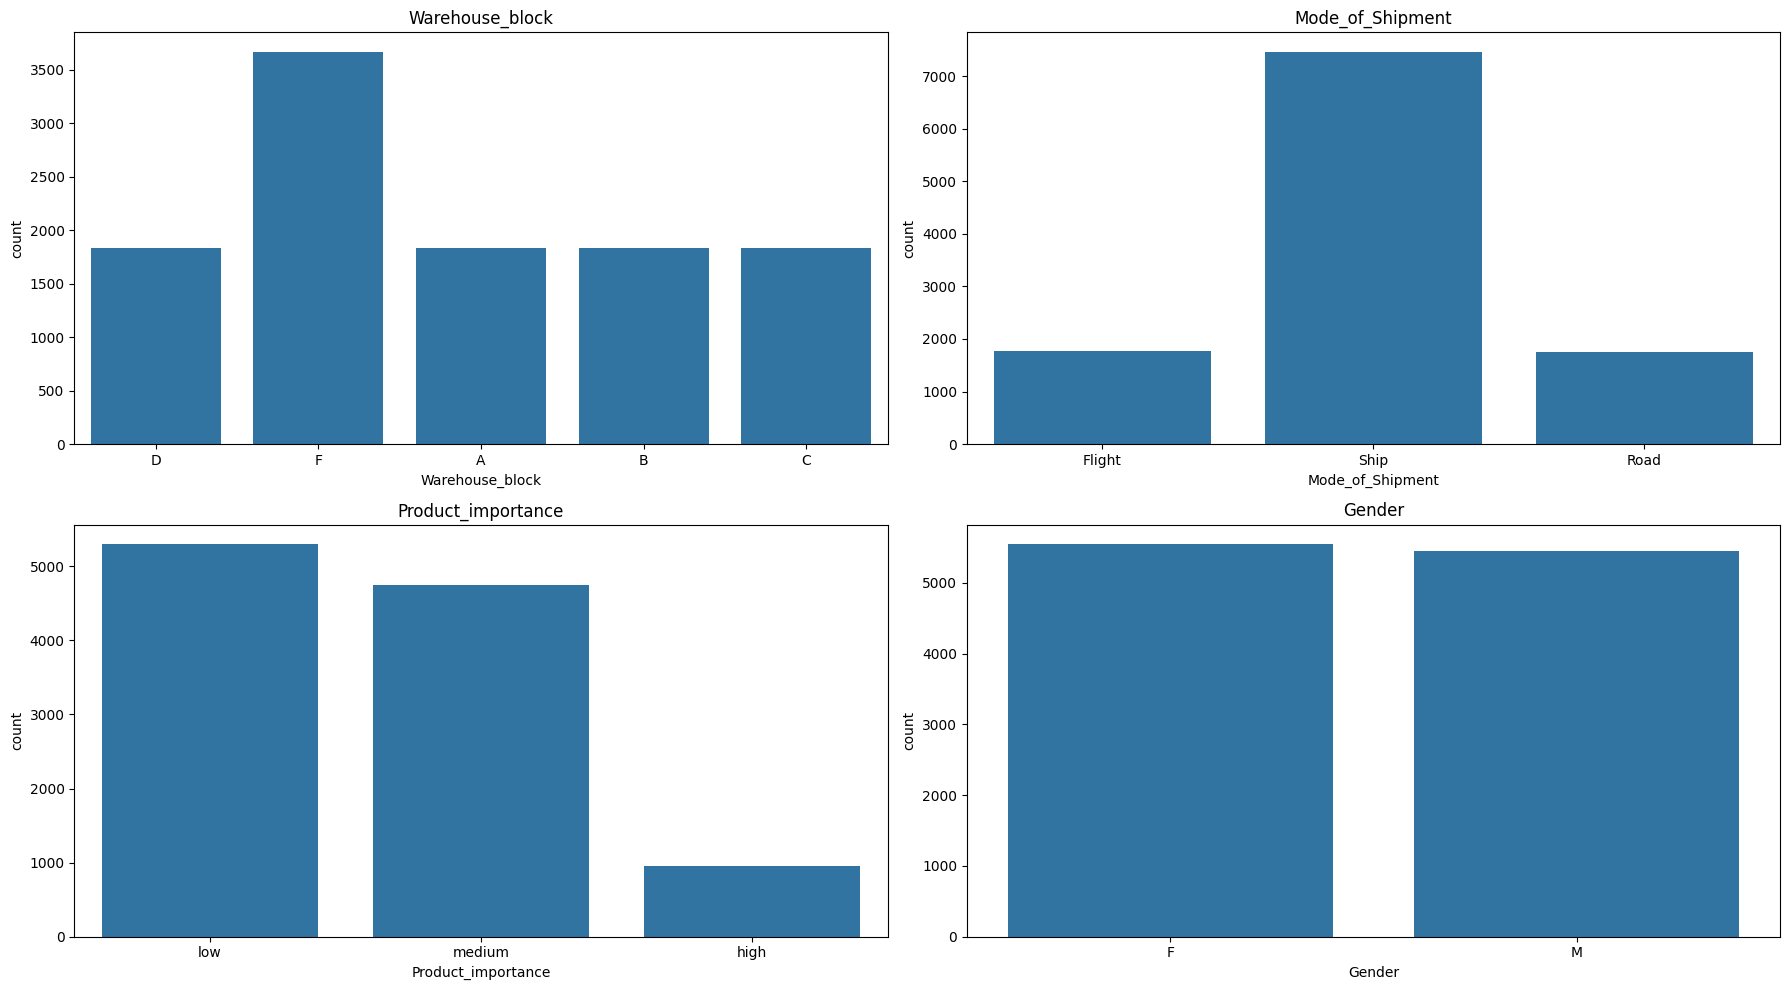

In [71]:
n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 4.3 |</span><span style='color:red'> Bivariate Analysis</span></b>

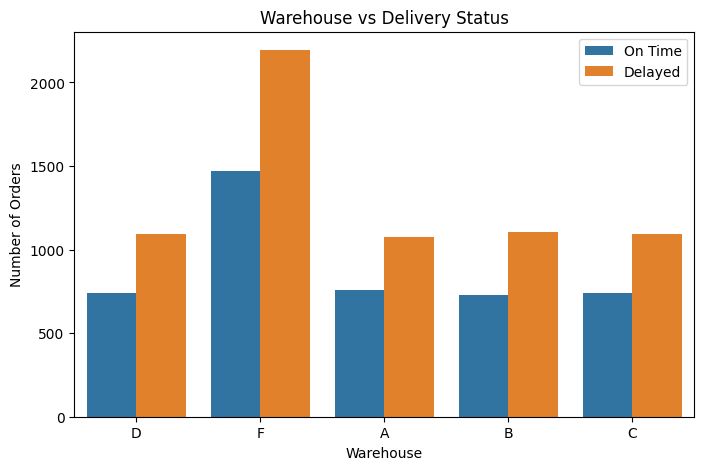

In [72]:
plt.figure(figsize=(8,5))

sns.countplot(x='Warehouse_block', hue='Reached.on.Time_Y.N', data=df)

plt.title("Warehouse vs Delivery Status")
plt.xlabel("Warehouse")
plt.ylabel("Number of Orders")
plt.legend(["On Time", "Delayed"])
plt.show()

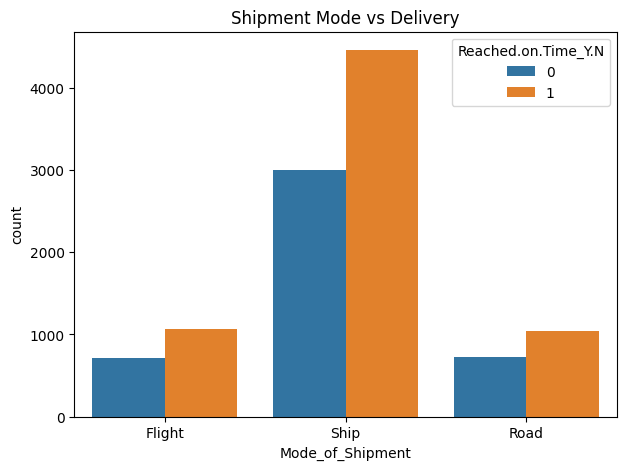

In [73]:
plt.figure(figsize=(7,5))

sns.countplot(x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', data=df)

plt.title("Shipment Mode vs Delivery")
plt.show()

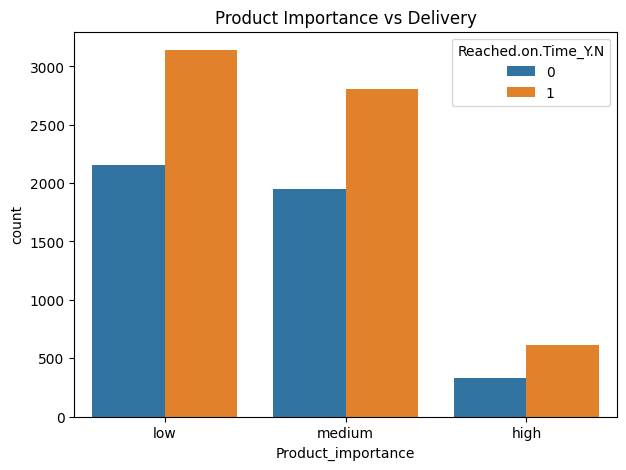

In [74]:
plt.figure(figsize=(7,5))

sns.countplot(x='Product_importance', hue='Reached.on.Time_Y.N', data=df)

plt.title("Product Importance vs Delivery")
plt.show()

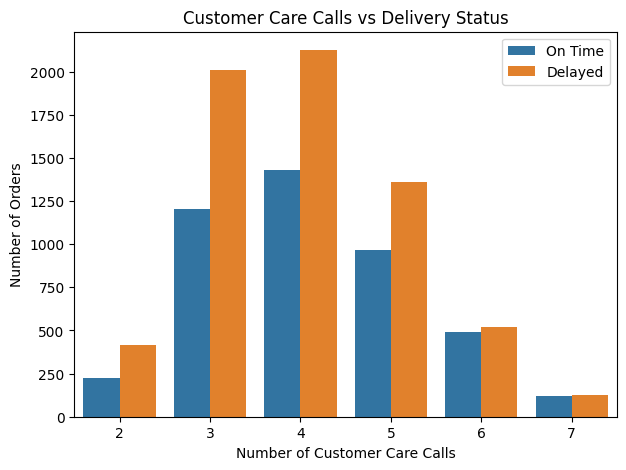

In [75]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Customer_care_calls", hue="Reached.on.Time_Y.N", data=df)

plt.title("Customer Care Calls vs Delivery Status")
plt.xlabel("Number of Customer Care Calls")
plt.ylabel("Number of Orders")
plt.legend(["On Time", "Delayed"])
plt.show()

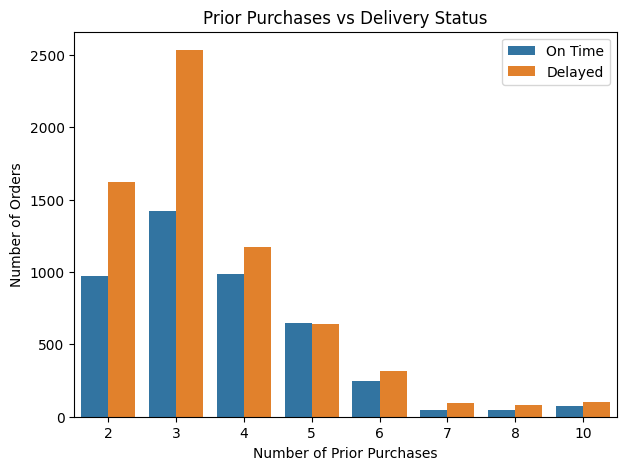

In [76]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Prior_purchases", hue="Reached.on.Time_Y.N", data=df)

plt.title("Prior Purchases vs Delivery Status")
plt.xlabel("Number of Prior Purchases")
plt.ylabel("Number of Orders")
plt.legend(["On Time", "Delayed"])
plt.show()

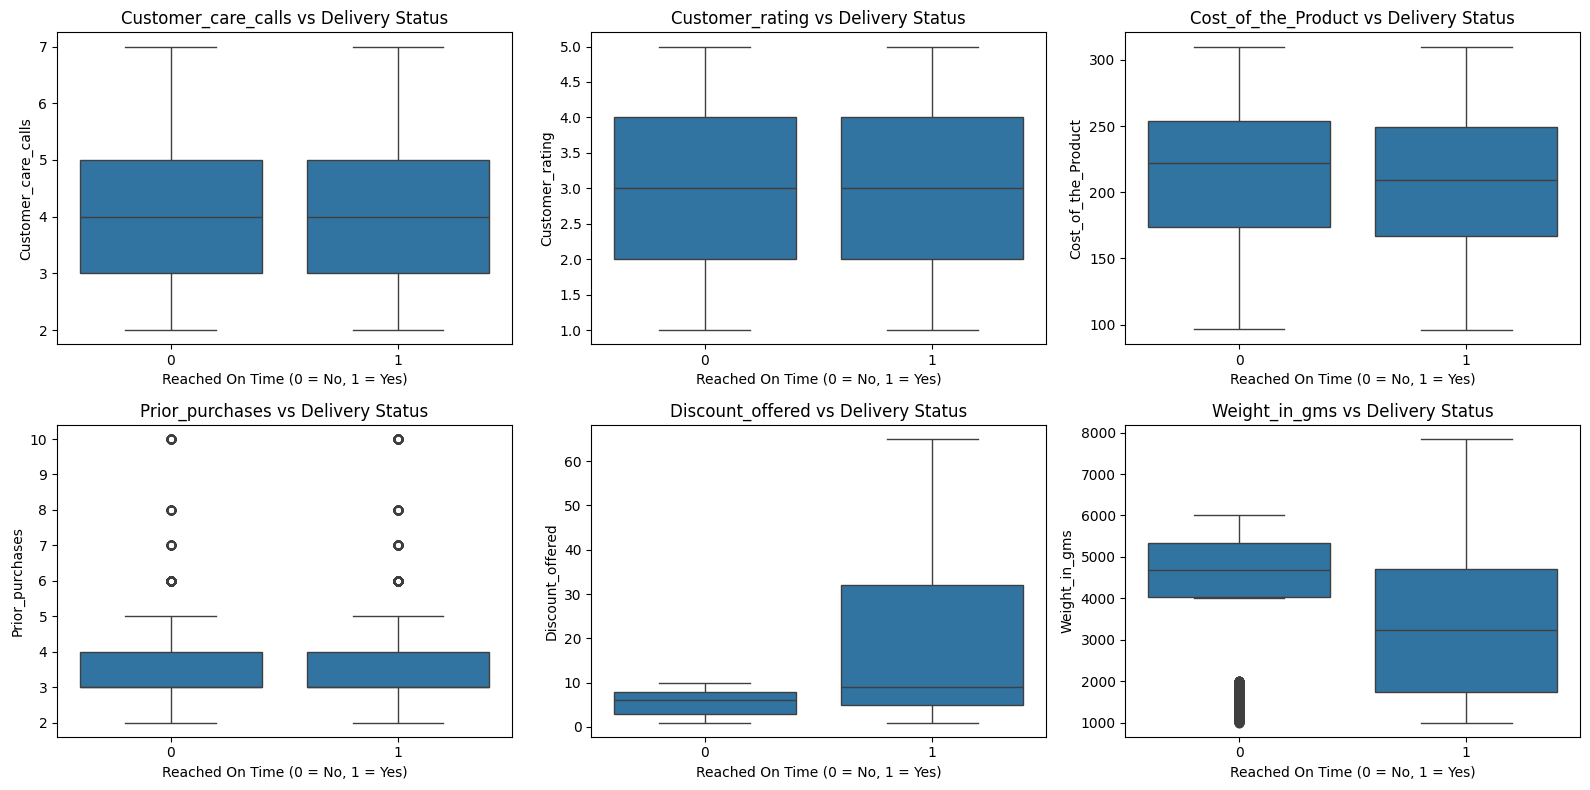

In [77]:
# Numeric features vs Delivery Status (boxplots)
# Shows how the distribution of each numeric feature differs between on-time and delayed orders
plt.figure(figsize=(16, 8))

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x="Reached.on.Time_Y.N", y=col, data=df)
    plt.title(f"{col} vs Delivery Status")
    plt.xlabel("Reached On Time (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()

<a id="correlationanalysis"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Correlation Analysis</p>

In [78]:
corr = df.corr(numeric_only=True)
corr

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
ID,1.000000,0.188998,-0.005722,0.196791,0.145369,-0.598278,0.278312,-0.411822
Customer_care_calls,0.188998,1.000000,0.012209,0.323182,0.180771,-0.130750,-0.276615,-0.067126
Customer_rating,-0.005722,0.012209,1.000000,0.009270,0.013179,-0.003124,-0.001897,0.013119
Cost_of_the_Product,0.196791,0.323182,0.009270,1.000000,0.123676,-0.138312,-0.132604,-0.073587
Prior_purchases,0.145369,0.180771,0.013179,0.123676,1.000000,-0.082769,-0.168213,-0.055515
Discount_offered,-0.598278,-0.130750,-0.003124,-0.138312,-0.082769,1.000000,-0.376067,0.397108
Weight_in_gms,0.278312,-0.276615,-0.001897,-0.132604,-0.168213,-0.376067,1.000000,-0.268793
Reached.on.Time_Y.N,-0.411822,-0.067126,0.013119,-0.073587,-0.055515,0.397108,-0.268793,1.000000


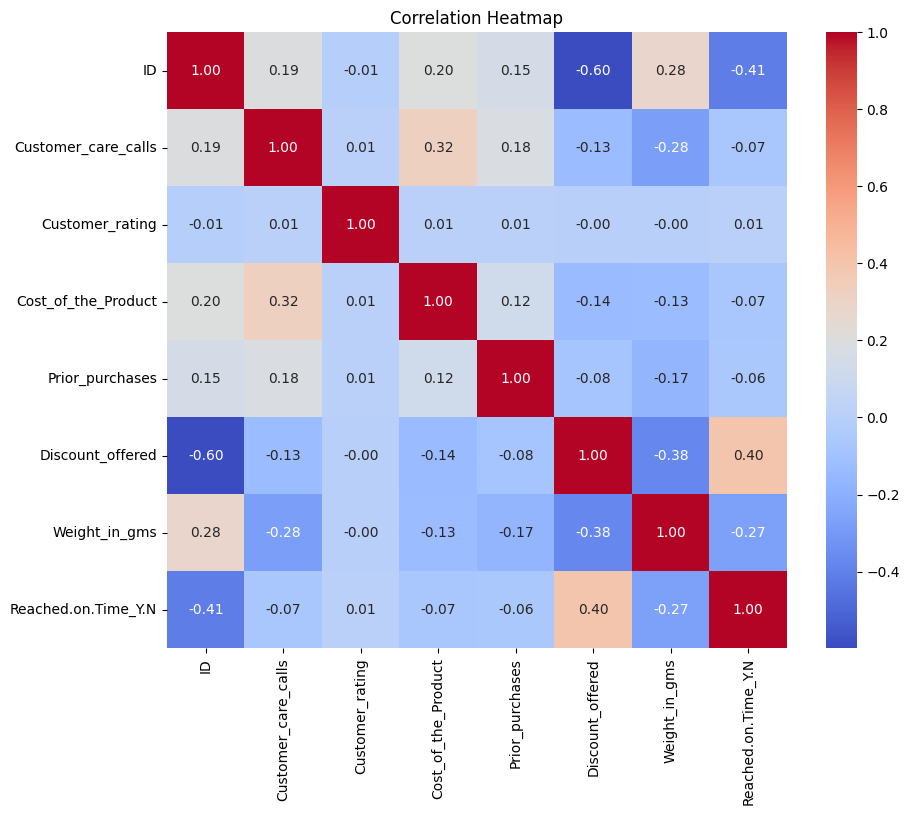

In [79]:
plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

Correlation Analysis checks two things at once:


Correlation with the target — e.g., Discount_offered shows a positive correlation (~0.40) with delay, while ID and Weight_in_gms show negative correlations with the target. This gives an early, purely statistical hint about which features may matter before you even build a model.

Multicollinearity between features — highly correlated predictors can destabilize coefficient estimates in Logistic Regression specifically (tree-based models are less affected). No extreme multicollinearity was evident here, so no features needed to be dropped purely for that reason.

<a id="datapreprocessing"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 6 | Data Pre-Processing</p>

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 6.1 |</span><span style='color:red'> Check Missing Value</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

zero missing values across all columns.

In [80]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 6.2 |</span><span style='color:red'> Check Duplicate Value</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

zero duplicate records across all columns.

In [81]:
df.duplicated().sum()

0

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 6.3 |</span><span style='color:red'> Analyze Outliers</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

These outliers are real-world values, not data-entry errors. A Discount_offered of 60–65% or a Prior_purchase near 10 is unusual but entirely realistic for an e-commerce catalogue that includes both regular-priced and heavily-promoted items. There's no evidence (e.g., negative weights, impossible costs) of measurement error — so removing them would mean deleting genuine business scenarios, not noise.


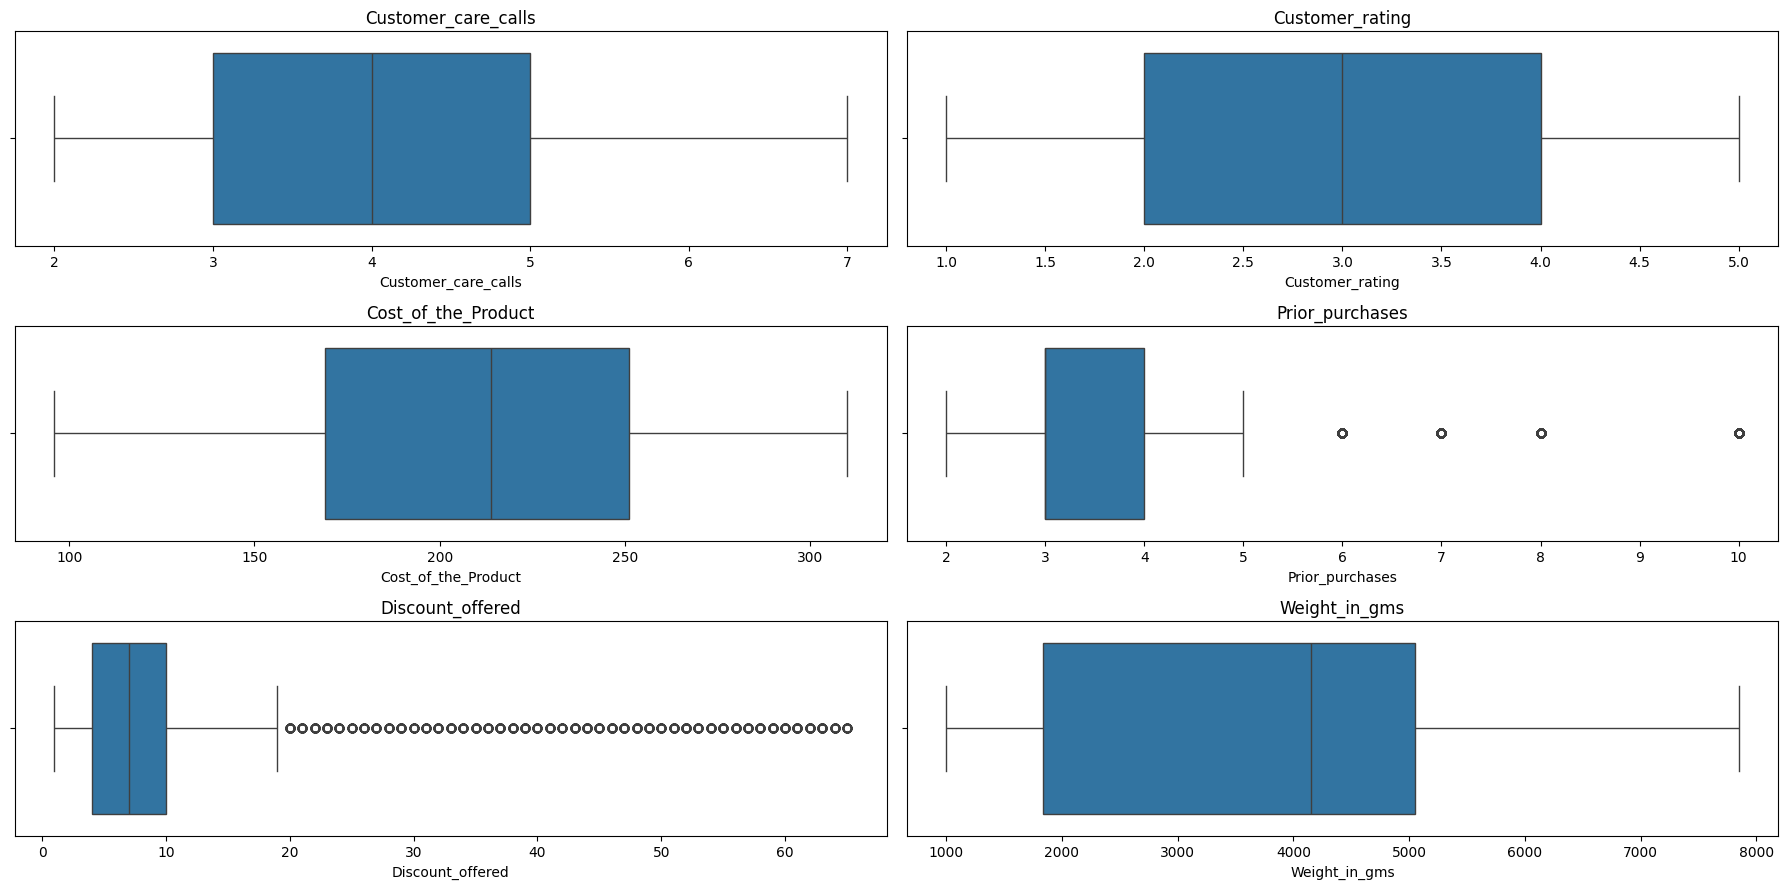

In [82]:
n_cols = 2
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()  # Convert 2D array to 1D

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 6.4 |</span><span style='color:red'> Feature Engineering</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

ID was dropped (it's just a row identifier with no predictive meaning — including it would let the model "memorize" arbitrary row order rather than learn genuine patterns)

Gender was also dropped. Delivery timeliness is a logistics phenomenon (warehouse, shipment mode, weight, discount patterns), not a function of the customer's gender. Including it would add noise at best, and could raise fairness/bias concerns at worst

In [83]:
# Prepare Features (X) and Target (y)
X = df.drop(["Reached.on.Time_Y.N", "ID", "Gender"], axis=1)
y = df["Reached.on.Time_Y.N"]

In [84]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Warehouse_block      10999 non-null  str  
 1   Mode_of_Shipment     10999 non-null  str  
 2   Customer_care_calls  10999 non-null  int64
 3   Customer_rating      10999 non-null  int64
 4   Cost_of_the_Product  10999 non-null  int64
 5   Prior_purchases      10999 non-null  int64
 6   Product_importance   10999 non-null  str  
 7   Discount_offered     10999 non-null  int64
 8   Weight_in_gms        10999 non-null  int64
dtypes: int64(6), str(3)
memory usage: 877.7 KB


____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Step 6.5 |</span><span style='color:red'> Encode Categorical Variables</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

(One-Hot Encoding) was applied to Warehouse_block, Mode_of_Shipment, Product_importance. These are nominal categories — there's no inherent order between "Warehouse A" and "Warehouse B", or between "Flight" and "Ship".

In [ ]:
X = pd.get_dummies(
    X,
    columns=[
        "Warehouse_block",
        "Mode_of_Shipment",
        "Product_importance"
    ],
    drop_first=True,
    dtype=int
)

In [86]:
X.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium
0,4,2,177,3,44,1233,0,0,1,0,0,0,1,0
1,4,5,216,2,59,3088,0,0,0,1,0,0,1,0
2,2,2,183,4,48,3374,0,0,0,0,0,0,1,0
3,3,3,176,4,10,1177,1,0,0,0,0,0,0,1
4,2,2,184,3,46,2484,0,1,0,0,0,0,0,1


<a id="traintestsplit"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 7 | Train-Test Split</p>

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

Result: 8,799 training rows / 2,200 test rows (80/20 split).

stratify=y specifically: Since the target has a 60/40 class split, stratification ensures the same proportion of delayed vs on-time orders appears in both the training and test sets. Without this, a random split could accidentally over- or under-represent one class in the test set, making the evaluation metrics misleading

In [88]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8799, 14)
(2200, 14)
(8799,)
(2200,)


<a id="featurescaling"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 8 | Feature Scaling</p>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

Features like Weight_in_gms (up to ~7,846) and Discount_offered (1–65) sit on completely different numeric scales than Customer_rating (1–5). Hence models like Logistic Regression and KNN requires scaled data.

In [89]:
numerical_cols = [
    "Customer_care_calls",
    "Customer_rating",
    "Cost_of_the_Product",
    "Prior_purchases",
    "Discount_offered",
    "Weight_in_gms"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

<a id="trainmodel"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 9 | Train the Model</p>

In [90]:
results = []

def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability scores (needed for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    if roc_auc is not None:
        print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # Save results for comparison
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    return model

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Model 1 |</span><span style='color:red'> Logistic Regression</span></b>

Logistic Regression
Accuracy : 0.6386
Precision: 0.7089
Recall   : 0.6695
F1 Score : 0.6886
ROC-AUC  : 0.7168

Classification Report

              precision    recall  f1-score   support

           0       0.55      0.59      0.57       887
           1       0.71      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



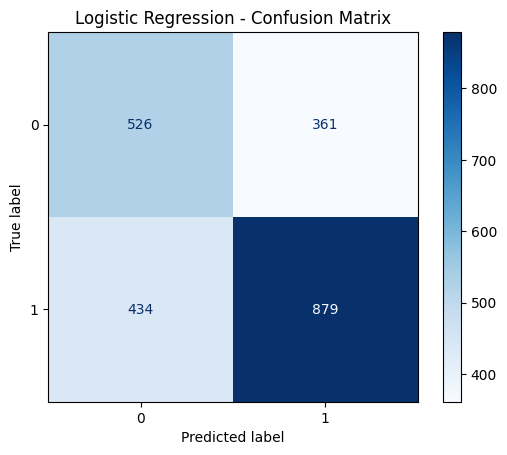

In [91]:
lr_model = evaluate_model(
    LogisticRegression(random_state=42, max_iter=1000),
    "Logistic Regression",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Model 2 |</span><span style='color:red'> Decision Tree Classifier</span></b>

Decision Tree
Accuracy : 0.6573
Precision: 0.7109
Recall   : 0.7174
F1 Score : 0.7142
ROC-AUC  : 0.6428

Classification Report

              precision    recall  f1-score   support

           0       0.58      0.57      0.57       887
           1       0.71      0.72      0.71      1313

    accuracy                           0.66      2200
   macro avg       0.64      0.64      0.64      2200
weighted avg       0.66      0.66      0.66      2200



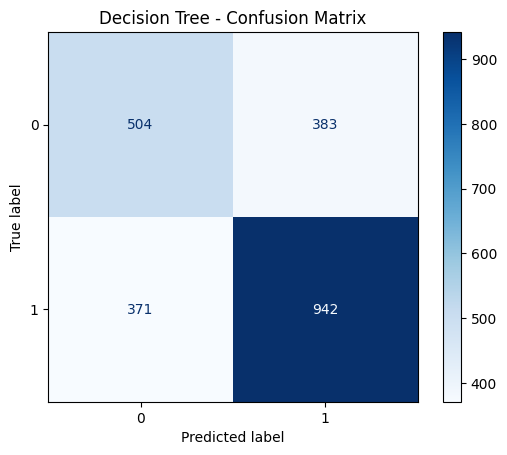

In [92]:
dt_model = evaluate_model(
    DecisionTreeClassifier(random_state=42),
    "Decision Tree",
    X_train,
    X_test,
    y_train,
    y_test
)

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Model 3 |</span><span style='color:red'> Random Forest</span></b>

Random Forest
Accuracy : 0.6586
Precision: 0.7602
Recall   : 0.6253
F1 Score : 0.6862
ROC-AUC  : 0.7349

Classification Report

              precision    recall  f1-score   support

           0       0.56      0.71      0.63       887
           1       0.76      0.63      0.69      1313

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.66      0.66      2200



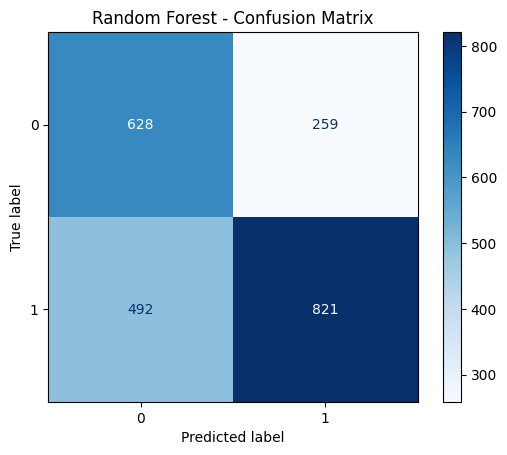

In [93]:
rf_model = evaluate_model(
    RandomForestClassifier(random_state=42),
    "Random Forest",
    X_train,
    X_test,
    y_train,
    y_test
)

____
<a id="cat_target"></a>
### <b><span style='color:#ff826e'>Model 4 |</span><span style='color:red'> KNN Model</span></b>

KNN
Accuracy : 0.6432
Precision: 0.7153
Recall   : 0.6679
F1 Score : 0.6908
ROC-AUC  : 0.7086

Classification Report

              precision    recall  f1-score   support

           0       0.55      0.61      0.58       887
           1       0.72      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.64      0.63      2200
weighted avg       0.65      0.64      0.65      2200



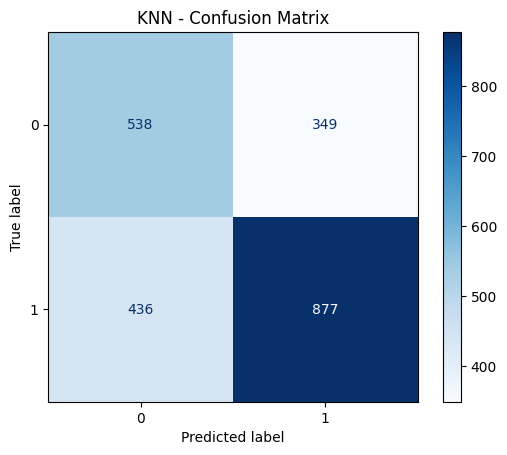

In [94]:
knn_model = evaluate_model(
    KNeighborsClassifier(),
    "KNN",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

<a id="accuracycomparision"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 10 | Accuracy comparision Matrix</p>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

Random Forest had the best overall balance — highest accuracy and the best ROC-AUC (ability to separate the two classes across thresholds), plus the highest precision (when it predicts "delayed," it's right more often).

In [95]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.658636,0.760185,0.625286,0.686168,0.734910
1,Decision Tree,0.657273,0.710943,0.717441,0.714177,0.642824
3,KNN,0.643182,0.715334,0.667936,0.690823,0.708616
0,Logistic Regression,0.638636,0.708871,0.669459,0.688602,0.716849


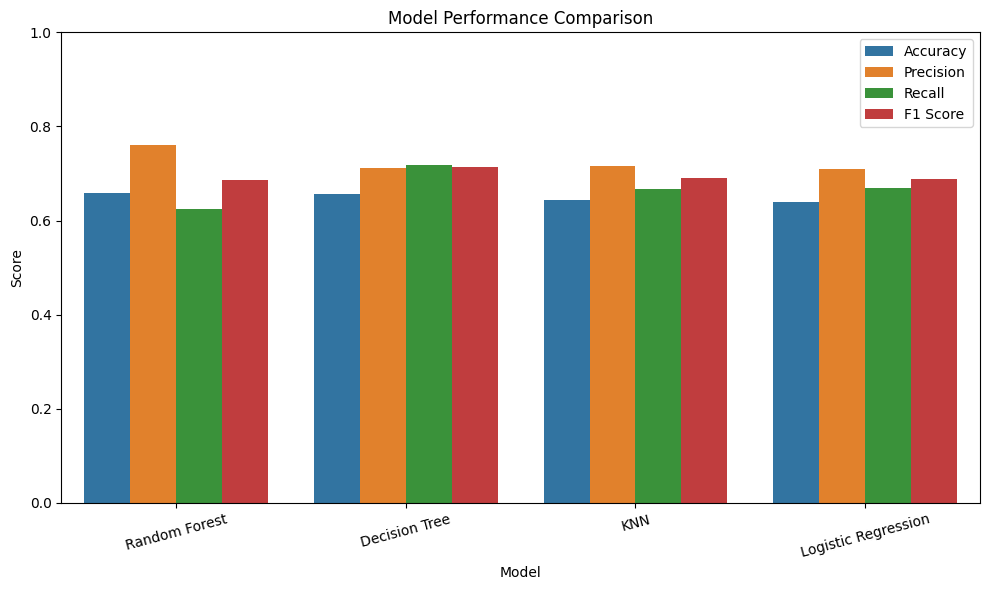

In [96]:
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

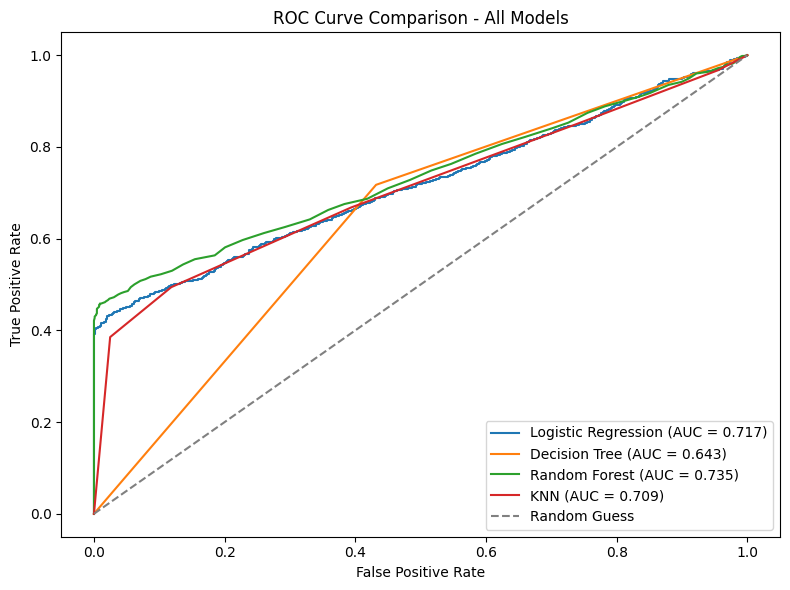

In [97]:
plt.figure(figsize=(8, 6))

models_for_roc = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Decision Tree": (dt_model, X_test),
    "Random Forest": (rf_model, X_test),
    "KNN": (knn_model, X_test_scaled)
}

for name, (model, X_test_data) in models_for_roc.items():
    y_prob = model.predict_proba(X_test_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

<a id="crossvalidation"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 11 | Cross-Validation</p>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

Why cross-validation is necessary ?

A single train/test split gives only one estimate of performance, which could be optimistic or pessimistic purely by chance depending on which rows landed in the test set. 5-fold cross-validation retrains and re-evaluates the model 5 times on different slices of the training data, giving a more reliable, less split-dependent estimate of how each model generalizes. It also reveals stability: Random Forest not only has the highest mean accuracy but a reasonably low standard deviation, indicating consistent performance across different data folds — reinforcing it as the strongest model.

StratifiedKFold (rather than plain KFold) was used to preserve the 60/40 class balance in every fold.

In [98]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [99]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [100]:
cv_results = []

for name, model in models.items():

    # Scale-dependent models
    if name in ["Logistic Regression", "KNN"]:
        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=skf,
            scoring="accuracy"
        )
    else:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=skf,
            scoring="accuracy"
        )

    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std Dev": scores.std(),
        "Min Accuracy": scores.min(),
        "Max Accuracy": scores.max()
    })

In [101]:
cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values(by="Mean CV Accuracy", ascending=False)

,Model,Mean CV Accuracy,Std Dev,Min Accuracy,Max Accuracy
3,Random Forest,0.657007,0.013719,0.634659,0.676136
1,Decision Tree,0.645529,0.011428,0.633523,0.662500
2,KNN,0.640982,0.012502,0.620455,0.659091
0,Logistic Regression,0.639619,0.008724,0.627841,0.649233


<a id="tuning"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 12 | Tuning Random Forest Model</p>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

This is 216 combinations × 5 folds = 1,080 model fits, scored on accuracy.

Why tune only Random Forest, and why these parameters ?

    It was already the strongest baseline, so tuning it offers the highest return on effort ("optimize the winner").
    n_estimators controls ensemble size (more trees generally = more stable predictions, at the cost of compute).
    max_depth, min_samples_split, min_samples_leaf all control tree complexity — directly targeting the classic bias-variance tradeoff: shallow/constrained trees underfit, very deep/unconstrained trees overfit to training noise.
    max_features controls how many features each tree considers per split, which is central to how Random Forest de-correlates its      individual trees (its main advantage over a single Decision Tree).


Best parameters found: max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=200

In [102]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [10, 15, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [103]:
best_rf = grid_search.best_estimator_

<a id="evalbestmodel"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 13 | Evaluate Best Model</p>

Random Forest (Tuned)
Accuracy : 0.6823
Precision: 0.8896
Recall   : 0.5339
F1 Score : 0.6673
ROC-AUC  : 0.7436

Classification Report

              precision    recall  f1-score   support

           0       0.57      0.90      0.70       887
           1       0.89      0.53      0.67      1313

    accuracy                           0.68      2200
   macro avg       0.73      0.72      0.68      2200
weighted avg       0.76      0.68      0.68      2200



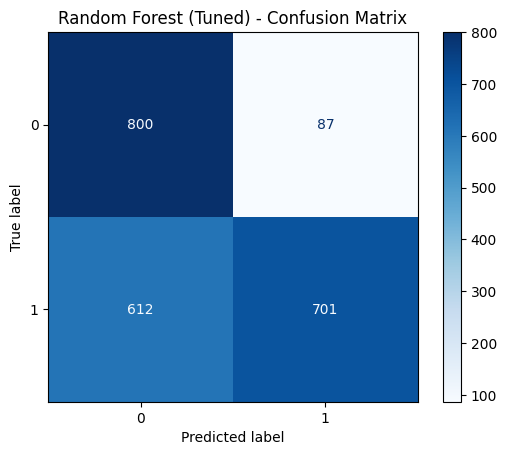

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [104]:
evaluate_model(
    best_rf,
    "Random Forest (Tuned)",
    X_train,
    X_test,
    y_train,
    y_test
)

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

Tuning clearly improved accuracy, precision, and ROC-AUC — the tuned model is much more confident and correct when it predicts "delayed" (89% precision vs 76%)

<a id="featureimportance"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 14 | Feature Importance of the best model</p>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

It tells the operations team, in plain terms: discount levels and package weight are, by far, the two biggest predictors of whether a shipment will be late — combined they account for over 70% of the model's decision-making.

In [105]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance

,Feature,Importance
4,Discount_offered,0.363483
5,Weight_in_gms,0.347579
2,Cost_of_the_Product,0.101967
3,Prior_purchases,0.059793
0,Customer_care_calls,0.040415
1,Customer_rating,0.027004
11,Mode_of_Shipment_Ship,0.009307
12,Product_importance_low,0.008344
13,Product_importance_medium,0.008085
9,Warehouse_block_F,0.007856


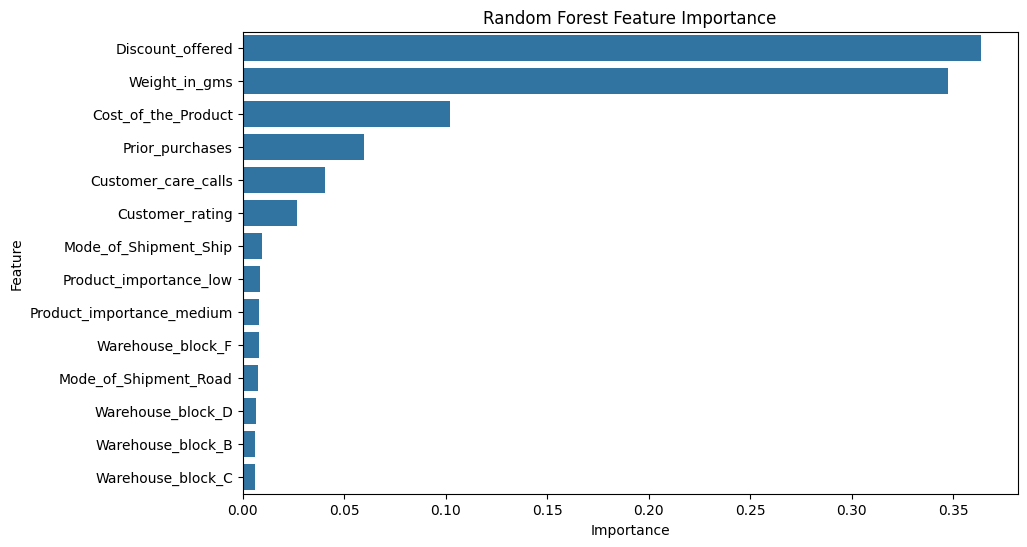

In [106]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

<a id="dumpmodel"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 15 | Dump Best Model Using Joblib</p>

In [107]:
dump(best_rf, "artifacts/model_rf.joblib")

['artifacts/model_rf.joblib']

<h2 align="left"><font color='red'>Best Regards!</font></h2>